In [ ]:
import json

with open("medaesqa_v1.json", "r") as f:
    data = json.load(f)

print(type(data))
print(len(data))
print(data[0])

<class 'list'>
40
{'question_id': '116', 'question': 'Are there ways to prevent sleep apnea or treat it naturally?', 'question_frame': {'Focus': 'sleep apnea', 'Type': 'Treatment', 'Task': 'Decision support', 'Subject matter (focus)': 'clinical / problem', 'Body system': 'respiratory', 'Specialty': 'pulmonology/ ENT / cardiology'}, 'expert_curated_answer': ' There are ways to prevent and treat sleep apnea naturally. Lifestyle changes may prevent and treat sleep apnea [28646811, 33659106, 28659501, 12693795, 36617387]. Sleep apnea can be prevented by losing weight and keeping it down with diet and exercise [33659106, 12693795, 30204000, 36617387, 28659501]; quitting alcohol and smoking [33659106, 12693795, 36617387]; and changing sleep position [12693795, 22987061, 30204000, 36617387]. While Continuous Positive Airway Pressure (CPAP, a machine that uses mild air pressure to keep breathing airways open while you sleep) is the standard treatment for obstructive sleep apnea (OSA) [28901030

**Reasoning**:
I will write a Python function that recursively maps out and prints the data types and keys of a nested dictionary or list to display the schema of the first record in the JSON dataset, specifically showing the deep structure of 'machine_generated_answers', 'answer_sentences', and 'citation_assessment'.



In [ ]:
def map_schema(data_item, indent=0):
    """Recursively traverses and maps the schema (keys and data types) of a nested structure."""
    space = "  " * indent
    if isinstance(data_item, dict):
        schema_dict = {}
        for k, v in data_item.items():
            if isinstance(v, dict):
                print(f"{space}{k} (dict):")
                map_schema(v, indent + 1)
            elif isinstance(v, list):
                if len(v) > 0 and isinstance(v[0], (dict, list)):
                    print(f"{space}{k} (list of {type(v[0]).__name__}):")
                    map_schema(v[0], indent + 1)
                else:
                    print(f"{space}{k} (list of basic types)")
            else:
                print(f"{space}{k} ({type(v).__name__})")
    elif isinstance(data_item, list):
        if len(data_item) > 0:
            print(f"{space}[list element] ({type(data_item[0]).__name__}):")
            map_schema(data_item[0], indent + 1)
        else:
            print(f"{space}empty list")
    else:
        print(f"{space}{type(data_item).__name__}")

print("=== Schema Mapping of the First Record ===")
map_schema(data[0])

=== Schema Mapping of the First Record ===
question_id (str)
question (str)
question_frame (dict):
  Focus (str)
  Type (str)
  Task (str)
  Subject matter (focus) (str)
  Body system (str)
  Specialty (str)
expert_curated_answer (str)
machine_generated_answers (dict):
  M1 (dict):
    answer (str)
    is_answer_accurate (str)
    answer_sentences (list of dict):
      answer_sentence_id (str)
      answer_sentence (str)
      answer_sentence_relevance (str)
      citation_assessment (list of dict):
        cited_pmid (str)
        evidence_support (str)
        evidence_relation (str)
  M2 (dict):
    answer (str)
    is_answer_accurate (str)
    answer_sentences (list of dict):
      answer_sentence_id (str)
      answer_sentence (str)
      answer_sentence_relevance (str)
      citation_assessment (NoneType)
  M3 (dict):
    answer (str)
    is_answer_accurate (str)
    answer_sentences (list of dict):
      answer_sentence_id (str)
      answer_sentence (str)
      answer_sentence_

# Task
Perform an exploratory data analysis of the dataset in "/content/medaesqa_v1.json" to understand its schema and evaluate the faithfulness and quality of machine-generated answers. This includes programmatically mapping out the complete nested data structure, analyzing key metric distributions such as answer accuracy, sentence relevance, and evidence relations, visualizing these patterns, and extracting illustrative examples of different faithfulness levels (fully supported, weakly/contradictory, and unreferenced sentences) to help establish a robust evaluation rubric.

## Examine Schema and Nesting

### Subtask:
Programmatically inspect and map out the complete nested data structure of a dataset record.


## Analyze Faithfulness and Evidence Metrics

### Subtask:
Analyze key metrics including answer accuracy, sentence relevance, and citation/evidence relations from the dataset.


**Reasoning**:
We will flatten the nested dataset to extract and calculate the distributions of model answer accuracy, sentence relevance, and evidence relations, printing the counts and percentages to fulfill the subtask instructions.



In [ ]:
from collections import Counter
import pandas as pd

accuracy_counts = []
sentence_relevance_counts = []
evidence_relation_counts = []

total_answers = 0
total_sentences = 0
total_citations = 0

for record in data:
    machine_answers = record.get("machine_generated_answers", {})
    for model_id, model_data in machine_answers.items():
        if not isinstance(model_data, dict):
            continue

        # 1. Answer level metrics
        accuracy = model_data.get("is_answer_accurate")
        accuracy_counts.append(str(accuracy))
        total_answers += 1

        # 2. Sentence level metrics
        sentences = model_data.get("answer_sentences", [])
        if isinstance(sentences, list):
            for sent in sentences:
                relevance = sent.get("answer_sentence_relevance")
                sentence_relevance_counts.append(str(relevance))
                total_sentences += 1

                # 3. Citation level metrics
                citations = sent.get("citation_assessment")
                if isinstance(citations, list):
                    for cit in citations:
                        relation = cit.get("evidence_relation")
                        evidence_relation_counts.append(str(relation))
                        total_citations += 1
                elif citations is not None:
                    # In case of non-list structure (e.g. single dict or string)
                    pass

print("=== Answer Accuracy Distribution ===")
acc_counter = Counter(accuracy_counts)
for k, v in acc_counter.items():
    pct = (v / total_answers) * 100
    print(f"{k}: {v} ({pct:.2f}%)")

print("\n=== Sentence Relevance Distribution ===")
rel_counter = Counter(sentence_relevance_counts)
for k, v in rel_counter.items():
    pct = (v / total_sentences) * 100
    print(f"{k}: {v} ({pct:.2f}%)")

print("\n=== Evidence Relation Distribution ===")
evid_counter = Counter(evidence_relation_counts)
for k, v in evid_counter.items():
    pct = (v / total_citations) * 100
    print(f"{k}: {v} ({pct:.2f}%)")


=== Answer Accuracy Distribution ===
yes: 1102 (91.83%)
no: 98 (8.17%)

=== Sentence Relevance Distribution ===
required: 3958 (76.68%)
borderline: 243 (4.71%)
unnecessary: 698 (13.52%)
None: 244 (4.73%)
inappropriate: 19 (0.37%)

=== Evidence Relation Distribution ===
supporting: 6490 (67.53%)
not relevant: 1551 (16.14%)
contradicting: 189 (1.97%)
neutral: 972 (10.11%)
invalid citation: 409 (4.26%)


## Visualize the data

### Subtask:
Visualize the distribution of sentence relevance and evidence relationship types using matplotlib or seaborn.


**Reasoning**:
Generate the visualization for sentence relevance and evidence relation distributions using seaborn and matplotlib.



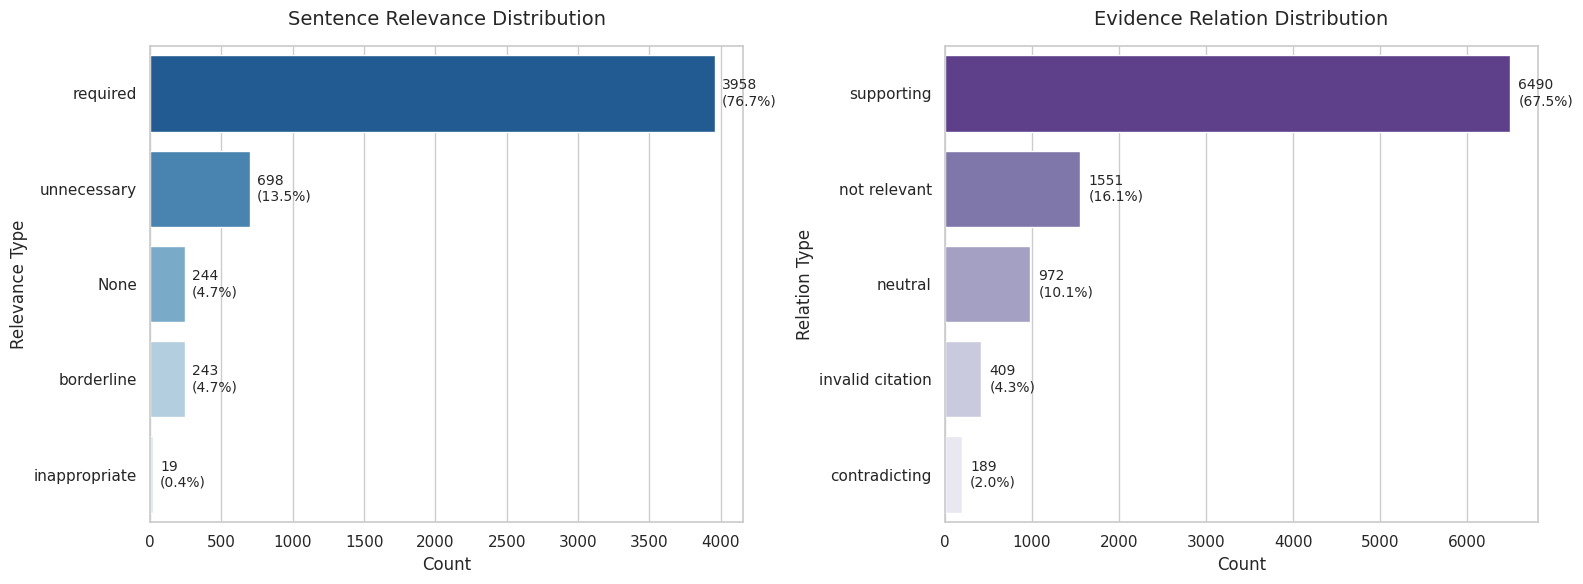

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for Sentence Relevance
relevance_df = pd.DataFrame(list(rel_counter.items()), columns=['Relevance', 'Count']).sort_values(by='Count', ascending=False)
# Prepare data for Evidence Relation
evidence_df = pd.DataFrame(list(evid_counter.items()), columns=['Relation', 'Count']).sort_values(by='Count', ascending=False)

# Plot 1: Sentence Relevance Distribution
sns.barplot(
    x='Count',
    y='Relevance',
    data=relevance_df,
    ax=axes[0],
    palette='Blues_r',
    hue='Relevance',
    legend=False
)
axes[0].set_title('Sentence Relevance Distribution', fontsize=14, pad=15)
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Relevance Type', fontsize=12)

# Annotate bars for Plot 1
for index, row in relevance_df.iterrows():
    pct = (row['Count'] / total_sentences) * 100
    axes[0].text(row['Count'] + 50, relevance_df.index.get_loc(index), f"{row['Count']}\n({pct:.1f}%)", va='center', ha='left', fontsize=10)

# Plot 2: Evidence Relation Distribution
sns.barplot(
    x='Count',
    y='Relation',
    data=evidence_df,
    ax=axes[1],
    palette='Purples_r',
    hue='Relation',
    legend=False
)
axes[1].set_title('Evidence Relation Distribution', fontsize=14, pad=15)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_ylabel('Relation Type', fontsize=12)

# Annotate bars for Plot 2
for index, row in evidence_df.iterrows():
    pct = (row['Count'] / total_citations) * 100
    axes[1].text(row['Count'] + 100, evidence_df.index.get_loc(index), f"{row['Count']}\n({pct:.1f}%)", va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

## Extract Concrete Examples for the Rubric

### Subtask:
Search for and extract specific, illustrative examples from the dataset representing different levels of faithfulness (fully supported, weakly/contradictory, and unreferenced sentences) to help build an evaluation rubric.


**Reasoning**:
Identify and extract three distinct concrete examples representing different levels of faithfulness (fully supported, weakly/contradictory, and unreferenced) to construct the evaluation rubric.



In [ ]:
fully_supported_example = None
weak_contradictory_example = None
unreferenced_example = None

for record in data:
    question = record.get("question", "")
    machine_answers = record.get("machine_generated_answers", {})
    for model_id, model_data in machine_answers.items():
        if not isinstance(model_data, dict):
            continue
        sentences = model_data.get("answer_sentences", [])
        if not isinstance(sentences, list):
            continue

        for sent in sentences:
            sent_text = sent.get("answer_sentence", "")
            relevance = sent.get("answer_sentence_relevance", "")
            citations = sent.get("citation_assessment")

            # 1. Unreferenced sentence
            if (citations is None or (isinstance(citations, list) and len(citations) == 0)) and not unreferenced_example:
                unreferenced_example = {
                    "question": question,
                    "model_id": model_id,
                    "sentence": sent_text,
                    "relevance": relevance,
                    "citation_assessment": None
                }

            # If there are citations, let's analyze their relations
            elif isinstance(citations, list) and len(citations) > 0:
                relations = [cit.get("evidence_relation") for cit in citations]

                # 2. Fully supported sentence
                if relevance == "required" and all(r == "supporting" for r in relations) and not fully_supported_example:
                    fully_supported_example = {
                        "question": question,
                        "model_id": model_id,
                        "sentence": sent_text,
                        "relevance": relevance,
                        "citations": citations
                    }

                # 3. Weak / Contradictory sentence
                if any(r in ["contradicting", "not relevant"] for r in relations) and not weak_contradictory_example:
                    weak_contradictory_example = {
                        "question": question,
                        "model_id": model_id,
                        "sentence": sent_text,
                        "relevance": relevance,
                        "citations": citations
                    }

        if fully_supported_example and weak_contradictory_example and unreferenced_example:
            break
    if fully_supported_example and weak_contradictory_example and unreferenced_example:
        break

print("=== 1. FULLY SUPPORTED SENTENCE EXAMPLE ===")
if fully_supported_example:
    print(f"Question: {fully_supported_example['question']}")
    print(f"Model ID: {fully_supported_example['model_id']}")
    print(f"Sentence: {fully_supported_example['sentence']}")
    print(f"Relevance: {fully_supported_example['relevance']}")
    for c in fully_supported_example['citations']:
        print(f"  - PMID: {c.get('cited_pmid')}")
        print(f"    Relation: {c.get('evidence_relation')}")
        print(f"    Evidence: {c.get('evidence_support')}")
else:
    print("Not found.")

print("\n=== 2. WEAK OR CONTRADICTORY SENTENCE EXAMPLE ===")
if weak_contradictory_example:
    print(f"Question: {weak_contradictory_example['question']}")
    print(f"Model ID: {weak_contradictory_example['model_id']}")
    print(f"Sentence: {weak_contradictory_example['sentence']}")
    print(f"Relevance: {weak_contradictory_example['relevance']}")
    for c in weak_contradictory_example['citations']:
        print(f"  - PMID: {c.get('cited_pmid')}")
        print(f"    Relation: {c.get('evidence_relation')}")
        print(f"    Evidence: {c.get('evidence_support')}")
else:
    print("Not found.")

print("\n=== 3. UNREFERENCED SENTENCE EXAMPLE ===")
if unreferenced_example:
    print(f"Question: {unreferenced_example['question']}")
    print(f"Model ID: {unreferenced_example['model_id']}")
    print(f"Sentence: {unreferenced_example['sentence']}")
    print(f"Relevance: {unreferenced_example['relevance']}")
else:
    print("Not found.")

=== 1. FULLY SUPPORTED SENTENCE EXAMPLE ===
Question: Are there ways to prevent sleep apnea or treat it naturally?
Model ID: M1
Sentence: There are several natural ways to prevent and treat sleep apnea [22014867].
Relevance: required
  - PMID: 22014867
    Relation: supporting
    Evidence: Dietary modifications may be an effective tool to improve the management of OSAS.

=== 2. WEAK OR CONTRADICTORY SENTENCE EXAMPLE ===
Question: Are there ways to prevent sleep apnea or treat it naturally?
Model ID: M1
Sentence: Additionally, oral appliances, conditioning to avoid the supine sleeping position, and inclined pillows can be used to treat mild to moderate sleep apnea [28126502, 30204000, 15162258].
Relevance: required
  - PMID: 28126502
    Relation: supporting
    Evidence: OAT has been recommended as an appropriate first-line treatment option for moderate obstructive sleep apnea-hypopnea syndrome (OSAHS) in patients without severe cardiovascular comorbidity.
  - PMID: 15162258
    Relat

## Final Task

### Subtask:
Summarize the key findings from the EDA, present the concrete examples of different faithfulness levels, and outline a draft framework for the faithfulness & hallucination rubric.


## Summary:

### Q&A

**What is the nested structure of the dataset `/content/medaesqa_v1.json`?**
The dataset contains deeply nested structured clinical evaluations:
*   **Top-Level Structure**: Includes keys such as `question_id`, `question`, `question_frame`, `expert_curated_answer`, `machine_generated_answers`, and `nuggets`.
*   **Model-Level Structure**: Inside `machine_generated_answers`, models (e.g., `M1` through `M30`) contain overall `answer` text, an `is_answer_accurate` label, and `answer_sentences`.
*   **Sentence-Level Structure**: Inside `answer_sentences`, each item tracks `answer_sentence_id`, the raw `answer_sentence` text, `answer_sentence_relevance` classifications, and a list of `citation_assessment` objects.
*   **Citation-Level Structure**: Inside `citation_assessment`, each citation maps to a `cited_pmid`, the exact text of the `evidence_support`, and an evaluation of the `evidence_relation` (e.g., supporting, contradicting).

---

### Data Analysis Key Findings

*   **Overall Answer Accuracy**: Machine-generated answers demonstrate high overall accuracy with **91.83% (1,102 answers)** classified as accurate (`yes`), and only **8.17% (98 answers)** flagged as inaccurate (`no`).
*   **Sentence Relevance**: The majority of the generated sentences are critical for addressing the questions, with **76.68% (3,958 sentences)** marked as `required`. Unnecessary sentences make up **13.52% (698 sentences)**, while borderline, inappropriate, or unspecified sentences account for the remaining **9.8%**.
*   **Evidence and Citations**: Out of 9,611 citations analyzed:
    *   **67.53% (6,490 citations)** directly back up the claims (`supporting`).
    *   **16.14% (1,551 citations)** provide no relevant context (`not relevant`).
    *   **10.11% (972 citations)** are `neutral`.
    *   **4.26% (409 citations)** refer to an `invalid citation`.
    *   **1.97% (189 citations)** directly conflict with the statements made in the generated text (`contradicting`).

---

### Insights or Next Steps

*   **Establish a Multi-Tiered Evaluation Rubric**: Use the extracted dataset examples to structure a formal rubric for model hallucinations. Models should be graded not only on raw text accuracy, but on granular alignment tiers: *Fully Supported* (100% supporting citations for required sentences), *Partially Supported/Weak* (presence of irrelevant, neutral, or unreferenced sentences), and *Contradictory/Hallucinated* (presence of contradicting citations or invalid PMIDs).
*   **Improve Citation Verification Pipelines**: Since over **22%** of generated citations are either "not relevant", "invalid", or "contradicting" despite the overall answer being marked as accurate, future system improvements must focus heavily on post-generation citation-checking and pruning.
